<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/CatBoostMulticlassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [16]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import ipywidgets as widgets
from IPython.display import display
import joblib
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# load  data from Iris Datasets
iris_df=load_iris()
# print the data keys
# print(iris_df)
X=iris_df.data
y=iris_df.target

In [7]:
#Split the data into training and testing sets

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


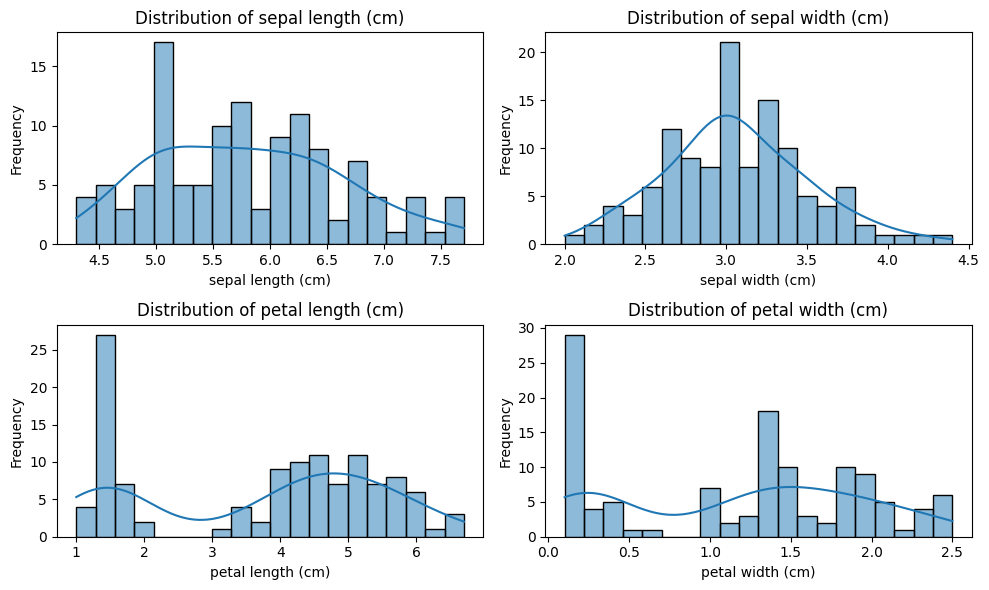

In [8]:
# Exploratory Data Analysis
plt.figure(figsize=(10,6))
for i,feature in enumerate(iris_df.feature_names):
  plt.subplot(2,2,i+1)
  sns.histplot(X_train[:,i],bins=20,kde=True)
  plt.title(f'Distribution of {feature}')
  plt.xlabel(feature)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
#

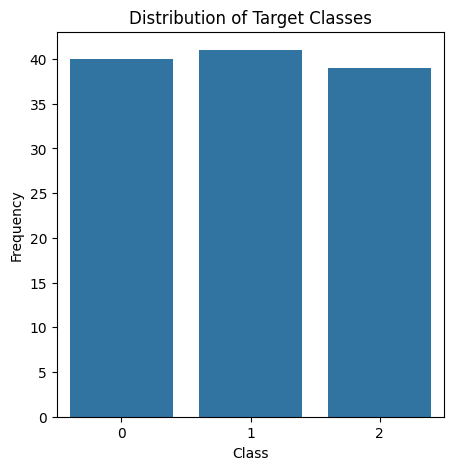

In [10]:
# Distribution of target classes
plt.figure(figsize=(5,5))
sns.countplot(x=y_train)
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

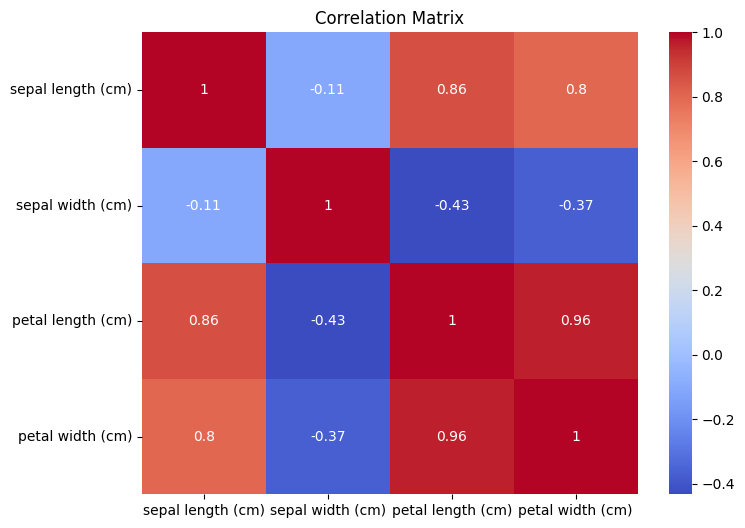

In [11]:
# Visualizing correlation matrix between features
#  will help us understand how they are related to each
#  other and also helpful for feature selection or engineering
# Corelation Matrix
# calculate the corealtion matrix for features in X_train
corr_matrix=np.corrcoef(X_train,rowvar=False)

# Create a heatmap to visualize the correlation matrix,
# annotating values, and using the 'coolwarm' color map
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',xticklabels=iris_df.feature_names,yticklabels=iris_df.feature_names)
#set title
plt.title('Correlation Matrix')
plt.show()

In [15]:
# Model Training
model=CatBoostClassifier(iterations=100,learning_rate=0.1,depth=6,
                         loss_function='MultiClass',verbose=False)
model.fit(X_train,y_train)

CatBoostClassifier(depth=6, iterations=100, learning_rate=0.1, loss_function='MultiClass', verbose=False)

In [20]:
# Predection and evluation
y_pred=model.predict(X_test)

# Evaluate the model
accuracy=accuracy_score(y_test,y_pred)
report = classification_report(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{report}')



Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [25]:
# save the model
joblib.dump(model,'iris_model.joblib')


['iris_model.joblib']

In [29]:
import os
print(os.listdir())

['.config', 'iris_model.joblib', 'catboost_info', 'sample_data']


In [33]:
# Load the trained model
model = joblib.load('iris_model.joblib')

# Create input widgets for user input
sepal_length = widgets.FloatText(description="Sepal Length:")
sepal_width = widgets.FloatText(description="Sepal Width:")
petal_length = widgets.FloatText(description="Petal Length:")
petal_width = widgets.FloatText(description="Petal Width:")

# Create a button for making predictions
predict_button = widgets.Button(description="Predict")

# Function to handle prediction on button click


def predict_on_click(b):
    # Collect user inputs and create an input array
    inputs = np.array([[sepal_length.value, sepal_width.value,
                        petal_length.value, petal_width.value]])
    # Use the model to predict probabilities
    probabilities = model.predict_proba(inputs)
    class_names = ["setosa", "versicolor", "virginica"]
    # Determine the predicted class and update the output label
    predicted_class_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_class_index]
    output_label.value = f"Predicted Iris Species: {predicted_class}"


predict_button.on_click(predict_on_click)

# Display the widgets
display(sepal_length, sepal_width, petal_length, petal_width, predict_button)

# Create an output label for displaying predictions
output_label = widgets.Label()
display(output_label)


FloatText(value=0.0, description='Sepal Length:')

FloatText(value=0.0, description='Sepal Width:')

FloatText(value=0.0, description='Petal Length:')

FloatText(value=0.0, description='Petal Width:')

Button(description='Predict', style=ButtonStyle())

Label(value='')